In [4]:
import sys
sys.path.append('../')


In [5]:
from predictor.sri_lanka_functions import *
from predictor.resampling_class import Resampling
from predictor.cross_country_functions import *

In [6]:
t = "overall_mar"
country = "LKA"
versioning="v3"

In [7]:

y, data_all = lka_data_preparation(new_features_fp="../data/lka/sri_lanka_features19_updated.csv", targets_fp="../data/lka/ML_targets_lka_updated.csv", t=t)

In [6]:
y.head()

,overall_mar
hhid,
11100111,1
11100121,0
11100131,1
11100141,1
11100151,0


In [7]:
data_all.drop(columns=["r3q", "rfh_avg", "food_exp_share"], inplace=True)

In [7]:
data_all.head()

,asset1,asset7,asset8,education2,food group1,food group2,food group3,food group4,food group5,food group6,food group7,food group8,food group9,housing1,housing2,housing4,labour1,labour2,labour4
hhid,,,,,,,,,,,,,,,,,,,
11108811,1.0,0.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0
11108831,1.0,1.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0
11108851,0.0,0.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0
11108861,1.0,1.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0
11108871,1.0,1.0,0.0,5.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [8]:
y[y==1]

,overall_mar
hhid,
11100111,1.0
11100121,NaN
11100131,1.0
11100141,1.0
11100151,NaN
...,...
19208551,1.0
19208561,NaN
19208571,1.0


In [8]:

resampling_lka = Resampling(
    y,
    data_all,
    target=t,
    country=country,
    versioning=versioning,
    algorithm="xgboost",
    sampling="undersampling",
    sampling_strategy=1,
    device="cpu"
)



In [9]:
lka_params, lka_perf = resampling_lka.xgboost_resampling_trainings()

In [10]:
overall_perf = resampling_lka.calculate_mean_std_performance(lka_perf, path='../data/results/{versioning}/')

In [11]:
resampling_lka.save_performance_results(overall_performance=overall_perf, 
                                        best_random_state=resampling_lka.get_best_model_random_state(lka_perf), 
                                        path='../data/results/')
resampling_lka.save_best_params(lka_params, 
                                best_random_state=resampling_lka.get_best_model_random_state(lka_perf), 
                                path='../data/results/')
resampling_lka.save_versioning_variables(data_all=data_all, path='../data/results/')

In [ ]:
print(resampling_lka.get_best_model_random_state(lka_perf))


146


### Classification:

!!! take the random state and best hyper-parameters after resampling 5 times:

In [ ]:
best_random_state = pd.read_csv('../data/results/perf_overall_mar_LKA_undersampling_v3_xgboost.csv').best_random_state[0]

FileNotFoundError: [Errno 2] No such file or directory: '../data/results/perf_overall_mar_LKA_undersampling_v3_xgboost.csv'

In [13]:
classification = Classification(y, data_all, type_target=t, random_state=0, sampling='undersampling', sampling_strategy=1)

In [ ]:
classification.type_target

'overall_mar'

In [ ]:
classification.train_test['X_train']

,asset1,asset7,asset8,education2,food group1,food group2,food group3,food group4,food group5,food group6,food group7,food group8,food group9,housing1,housing2,housing4,labour1,labour2,labour4
hhid,,,,,,,,,,,,,,,,,,,
13211621,0.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
12109921,1.0,0.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
171069101,1.0,0.0,0.0,3.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
11213081,0.0,1.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0
13305011,0.0,1.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12200741,0.0,0.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
12306441,0.0,0.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
17204771,1.0,1.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0


In [ ]:
dummy = classification.dummy_classification()

In [ ]:
dummy_pred = classification.predictions(dummy)

In [ ]:
dummy_performance_indicators = classification.perf_ind_classification(dummy_pred)

In [ ]:
dummy_performance_indicators

{'accuracy': 0.489,
 'balanced accuracy': 0.489,
 'adj_balanced_accuracy': -0.022,
 'recall': 0.5,
 'precision': 0.505,
 'specificity': np.float64(0.522),
 'f1_score': 0.502}

In [14]:
model = classification.xgbclassification_best_model('../data/results/besthyper_overall_mar_LKA_undersampling_v3_xgboost.csv')

c:\Users\andreas\mimi-ml\paper_notebooks\..\predictor\classification_class.py:181: Warning: warning from our end: to use this function you first need to reset the random_state parameter of the classification class with the number that gives the best model performance after multiple trainings
  warnings.warn("warning from our end: to use this function you first need to reset the random_state parameter of the classification"


In [15]:
predictions = classification.predictions(model)

In [16]:
performance_indicators = classification.perf_ind_classification(predictions)

In [17]:
performance_indicators

{'accuracy': 0.642,
 'balanced accuracy': 0.642,
 'adj_balanced_accuracy': 0.285,
 'recall': 0.632,
 'precision': 0.66,
 'specificity': np.float64(0.347),
 'f1_score': 0.646}

In [18]:
threshold_probability = 0.5

In [19]:
#Generate dictionary for adjusted performance indicators
adjusted_performance_indicators = {}

#probalilities
y_proba = classification.y_proba(model)

#---Performance---
if threshold_probability != None:
    predictions = predictions_proba(y_proba, threshold_probability)
else:
    predictions = classification.predictions(model)

array_precision, array_recall, average_pre_recall = calculates_precision_recall_auc(y_proba, classification, drop_intermediate=True)
#append average_pre_recall on performance_indicators
performance_indicators['average_pre_recall'] = average_pre_recall
array_fpr, array_tpr, rocauc_score = calculates_roc_auc(y_proba, classification, drop_intermediate=True)
#append roc scores on performance_indicators
performance_indicators['rocauc_score'] = rocauc_score
#calculate adjusted precision-recall and roc values and save them on the adjusted_performance_indicators
adjusted_roc_auc, adjusted_average_pre_recall = get_adjusted_values(classification, rocauc_score, average_pre_recall)
adjusted_performance_indicators['adjusted_rocauc'] = adjusted_roc_auc
adjusted_performance_indicators['adjusted_average_pre_recall'] = adjusted_average_pre_recall

In [20]:
rocauc_score, average_pre_recall, adjusted_roc_auc, adjusted_average_pre_recall

(0.7007327557704549, 0.72, 0.4, 0.42)

In [22]:
adjusted_performance_indicators

{'adjusted_rocauc': 0.4, 'adjusted_average_pre_recall': 0.42}

In [23]:
shap_values=classification.shap_values(model)

In [24]:
explanations = pd.read_csv('../data/features_explanations.csv', index_col=0)
dict_all = explanations.set_index('codename')['explanation'].to_dict()

In [25]:
trainset = classification.train_test['X_train']

In [26]:
trainset = replace_features_col_names(trainset, dict_all)

findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.


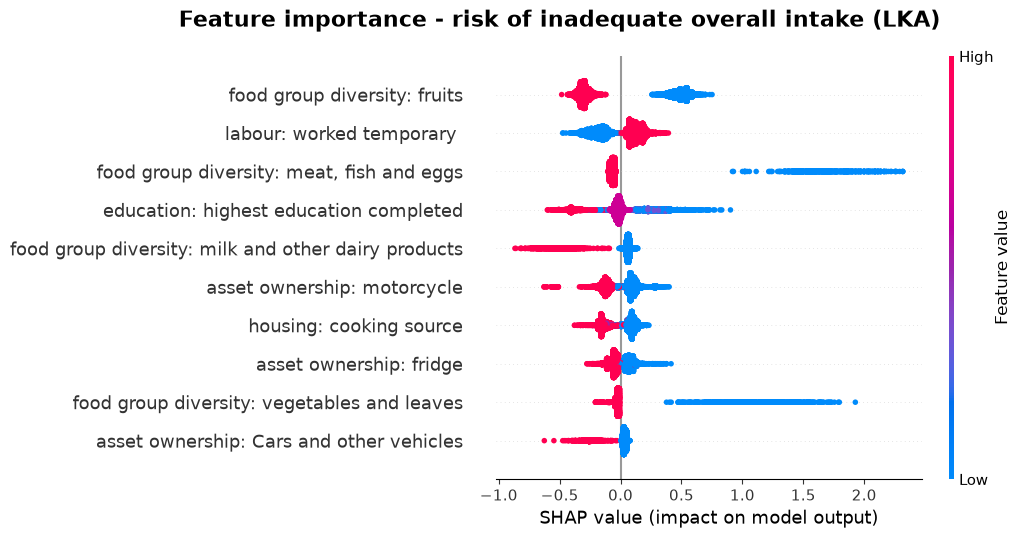

In [27]:
classification.shap_summary_plot(model, trainset, title="Feature importance - risk of inadequate overall intake (LKA)", display=10, iso3='ETH', titlefontsize=16, save=False)


In [28]:

# Import TreeAnalyzer for trajectory-based explainability
import sys
sys.path.append('../')

from explainer.analysis.tree_analyzer import TreeAnalyzer

# Initialize TreeAnalyzer with the classification object
tree_analyzer = TreeAnalyzer(classification)


In [29]:

# Compute trajectory metrics (Feature Acceleration & Feature Confusion Index)
trajectory_metrics = tree_analyzer.compute_trajectory_metrics(model.get_booster())

print("Trajectory Metrics Computed for Features:")
for feature_idx, metrics in sorted(trajectory_metrics.items())[:5]:  # Show top 5
    print(f"\nFeature {feature_idx}: {metrics['feature_name']}")
    print(f"  - Iterations used: {len(metrics['iterations'])}")
    print(f"  - Total gain: {round(sum(metrics['gains']), 4)}")
    print(f"  - Avg FCI: {round(np.mean(metrics['fci']), 4)}")
    print(f"  - Acceleration range: [{round(min(metrics['acceleration']), 4)}, {round(max(metrics['acceleration']), 4)}]")


Trajectory Metrics Computed for Features:

Feature 0: asset1
  - Iterations used: 137
  - Total gain: 739.5934
  - Avg FCI: 363.7425
  - Acceleration range: [-37.5732, 42.8123]

Feature 1: asset7
  - Iterations used: 178
  - Total gain: 898.6202
  - Avg FCI: 482.0106
  - Acceleration range: [-31.0176, 30.2233]

Feature 2: asset8
  - Iterations used: 100
  - Total gain: 668.7737
  - Avg FCI: 1139.8573
  - Acceleration range: [-51.1619, 69.5882]

Feature 3: education2
  - Iterations used: 193
  - Total gain: 2730.9097
  - Avg FCI: 871.8258
  - Acceleration range: [-103.4133, 157.5302]

Feature 4: food group1
  - Iterations used: 12
  - Total gain: 2.0786
  - Avg FCI: 5.8835
  - Acceleration range: [-0.0663, 0.2576]


In [30]:

# Analyze behavioral signatures for all features
print("=" * 80)
print("FEATURE BEHAVIORAL SIGNATURES")
print("=" * 80)

behavioral_signatures = {}
for feature_idx in sorted(trajectory_metrics.keys()):
    signature = tree_analyzer.get_behavioral_signature(trajectory_metrics, feature_idx)
    behavioral_signatures[feature_idx] = signature
    
    print(f"\n[{feature_idx}] {signature['feature_name']}")
    print(f"    Signature: {signature['signature']}")
    print(f"    Total Gain: {signature['total_gain']:.4f}")
    print(f"    Avg FCI: {signature['avg_fci']:.4f}")
    print(f"    Early Acceleration: {signature['early_acceleration_mean']:.6f}")
    print(f"    Late Acceleration: {signature['late_acceleration_mean']:.6f}")
    print(f"    Acceleration Volatility: {signature['acceleration_volatility']:.6f}")
    print(f"    Iterations Used: {signature['num_iterations']}")


FEATURE BEHAVIORAL SIGNATURES

[0] asset1
    Signature: OUTLIER SPECIALIST: Continuous late-stage optimization
    Total Gain: 739.5934
    Avg FCI: 0.2092
    Early Acceleration: 0.016600
    Late Acceleration: 0.005900
    Acceleration Volatility: 9.153200
    Iterations Used: 137

[1] asset7
    Signature: CORE DRIVER: Early optimization, then stabilization
    Total Gain: 898.6202
    Avg FCI: 0.1542
    Early Acceleration: 0.014200
    Late Acceleration: -0.008300
    Acceleration Volatility: 8.018900
    Iterations Used: 178

[2] asset8
    Signature: CORE DRIVER: Early optimization, then stabilization
    Total Gain: 668.7737
    Avg FCI: 0.2124
    Early Acceleration: 0.072100
    Late Acceleration: -0.039700
    Acceleration Volatility: 13.507400
    Iterations Used: 100

[3] education2
    Signature: OUTLIER SPECIALIST: Continuous late-stage optimization
    Total Gain: 2730.9097
    Avg FCI: 0.2115
    Early Acceleration: 0.005400
    Late Acceleration: 0.006500
    Acceler


## Behavioral Signatures Visualization

Plot Feature Acceleration vs. Feature Confusion Index to reveal model learning patterns:
- **Acceleration (A_f)**: Second derivative of cumulative gain—measures if the model is "striking a richer vein" or "running out of steam"
- **FCI (Feature Confusion Index)**: Average Hessian/confusion per split—measures if a feature splits macro uncertainty or micro puddles


In [31]:

import matplotlib
matplotlib.use('Agg')  # Headless background rendering
import matplotlib.pyplot as plt

# Generate behavioral signatures plot
fig, axes = tree_analyzer.plot_behavioral_signatures(
    trajectory_metrics, 
    figsize=(16, 12),
    save_path='behavioral_signatures_lka.png'
)
plt.show()


Plot saved to behavioral_signatures_lka.png


C:\Users\andreas\AppData\Local\Temp\ipykernel_22072\3034468603.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [32]:
import matplotlib
matplotlib.use('Agg')  # Enforces headless background rendering
import matplotlib.pyplot as plt

# Initialize canvas size and ratio
fig = plt.figure(figsize=(11, 7.5), dpi=200)
ax = fig.add_subplot(111)
fig.patch.set_facecolor('#ffffff')

# 1. Root Node Box (Blue styling indicating initial state)
root_text = (
    "ROOT NODE\n"
    "1,000 Physical Rows Entering Tree\n"
    "All rows uncalibrated (p ≈ 0.5)\n"
    "Individual Hessian (h) = 0.25\n"
    "-----------------------------------------\n"
    "TOTAL NODE COVER = 250.0"
)
ax.text(0.5, 0.88, root_text, ha='center', va='center', fontsize=15,
        bbox=dict(facecolor='#e8f4fd', edgecolor='#2b8cbe', boxstyle='round,pad=1.0', lw=2))

# 2. Split Condition Node (Gray intermediate anchor)
ax.text(0.5, 0.58, "Split Condition:\n[ Age < 30 ]", ha='center', va='center', fontsize=15, weight='bold',
        bbox=dict(facecolor='#f1f3f5', edgecolor='#adb5bd', boxstyle='square,pad=0.6', lw=1.5))

# 3. Left Branch Box (Yellow indicating high uncertainty/weight)
left_text = (
    "[ Left Branch: Age < 30 ]\n"
    "500 Physical Rows\n\n"
    "Rows are highly CONFUSED\n"
    "Average p_i = 0.50\n"
    "Individual h_i = 0.25\n"
    "---------------------------------------\n"
    "NODE COVER = 125.0"
)
ax.text(0.18, 0.22, left_text, ha='center', va='center', fontsize=15,
        bbox=dict(facecolor='#fff9db', edgecolor='#fab005', boxstyle='round,pad=0.9', lw=2))

# 4. Right Branch Box (Green indicating high confidence/flattened weight)
right_text = (
    "[ Right Branch: Age >= 30 ]\n"
    "500 Physical Rows\n\n"
    "Rows are highly CONFIDENT\n"
    "Average p_i = 0.99\n"
    "Individual h_i = 0.0099\n"
    "---------------------------------------\n"
    "NODE COVER = 4.95"
)
ax.text(0.82, 0.22, right_text, ha='center', va='center', fontsize=15,
        bbox=dict(facecolor='#ebfbee', edgecolor='#40c057', boxstyle='round,pad=0.9', lw=2))

# 5. Drawing Structural Connectors
ax.plot([0.5, 0.5], [0.74, 0.64], color='#495057', lw=2)    # Root down to split
ax.plot([0.5, 0.18], [0.52, 0.38], color='#495057', lw=2)   # Split down to left node
ax.plot([0.5, 0.82], [0.52, 0.38], color='#495057', lw=2)   # Split down to right node

# Bound cleanup and axis removal
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Title presentation
plt.title("XGBoost Structural Asymmetry: Node Cover vs. Physical Sample Count", fontsize=14, weight='bold', pad=20)

# Save high-resolution PNG
plt.savefig('node_cover_diagram.png', dpi=300, bbox_inches='tight')
plt.close()


In [33]:
from predictor.visualisations import visualise_actual_predicted_map
import polars as pl


In [34]:
geo_df = pl.read_csv("../data/lka/geodata_sri_lanka.csv")   

In [35]:
roster = pl.read_csv("../data/lka/new_roster_lka.csv")

In [ ]:
roster


,district,relationship,person_serial_no,household_id,adm1Geometry,adm1Code,adm1Name,adm2Code,adm2Name,adm2Geometry,adm2Name_y
i64,str,i64,i64,i64,str,i64,str,i64,str,str,str
0,"""Colombo""",1,1,11108811,"""POLYGON ((80.1789 6.8028, 80.1…",2744,"""Western""",25851,"""Colombo""","""POLYGON ((79.9011 6.7153, 79.9…","""Colombo"""
1,"""Colombo""",2,2,11108811,"""POLYGON ((80.1789 6.8028, 80.1…",2744,"""Western""",25851,"""Colombo""","""POLYGON ((79.9011 6.7153, 79.9…","""Colombo"""
2,"""Colombo""",3,3,11108811,"""POLYGON ((80.1789 6.8028, 80.1…",2744,"""Western""",25851,"""Colombo""","""POLYGON ((79.9011 6.7153, 79.9…","""Colombo"""
3,"""Colombo""",3,4,11108811,"""POLYGON ((80.1789 6.8028, 80.1…",2744,"""Western""",25851,"""Colombo""","""POLYGON ((79.9011 6.7153, 79.9…","""Colombo"""
4,"""Colombo""",1,1,11108831,"""POLYGON ((80.1789 6.8028, 80.1…",2744,"""Western""",25851,"""Colombo""","""POLYGON ((79.9011 6.7153, 79.9…","""Colombo"""
…,…,…,…,…,…,…,…,…,…,…,…
79591,"""Kegalle""",1,1,192085101,"""POLYGON ((80.4211 7.3542, 80.4…",2741,"""Sabaragamuwa""",25844,"""Kegalle""","""POLYGON ((80.495 6.8316, 80.49…","""Kegalle"""
79592,"""Kegalle""",2,2,192085101,"""POLYGON ((80.4211 7.3542, 80.4…",2741,"""Sabaragamuwa""",25844,"""Kegalle""","""POLYGON ((80.495 6.8316, 80.49…","""Kegalle"""
79593,"""Kegalle""",3,3,192085101,"""POLYGON ((80.4211 7.3542, 80.4…",2741,"""Sabaragamuwa""",25844,"""Kegalle""","""POLYGON ((80.495 6.8316, 80.49…","""Kegalle"""


In [36]:
roster = roster.group_by("household_id").agg(
    pl.col("district").first().alias("district"),
    pl.col("adm1Code").first().alias("adm1Code"),
    pl.col("adm1Name").first().alias("adm1Name"),
    pl.col("adm2Code").first().alias("adm2Code"),
    pl.col("adm2Name").first().alias("adm2Name")
).sort("household_id")


In [37]:
roster

household_id,district,adm1Code,adm1Name,adm2Code,adm2Name
i64,str,i64,str,i64,str
11100111,"""Colombo""",2744,"""Western""",25851,"""Colombo"""
11100121,"""Colombo""",2744,"""Western""",25851,"""Colombo"""
11100131,"""Colombo""",2744,"""Western""",25851,"""Colombo"""
11100141,"""Colombo""",2744,"""Western""",25851,"""Colombo"""
11100151,"""Colombo""",2744,"""Western""",25851,"""Colombo"""
…,…,…,…,…,…
192078101,"""Kegalle""",2741,"""Sabaragamuwa""",25844,"""Kegalle"""
192080101,"""Kegalle""",2741,"""Sabaragamuwa""",25844,"""Kegalle"""
192082101,"""Kegalle""",2741,"""Sabaragamuwa""",25844,"""Kegalle"""


In [38]:
roster.write_csv("../data/lka/hh_geo_mapping.csv")

In [39]:
geo_df

,adm1Geometry,adm1Code,adm1Name,adm2Code,adm2Name_x,adm2Geometry,adm2Name_y
i64,str,i64,str,i64,str,str,str
0,"""POLYGON ((80.9883 7.7204, 80.9…",2736,"""Central""",41748,"""Kandy""","""POLYGON ((80.974 7.4887, 80.96…","""Kandy"""
1,"""POLYGON ((80.9883 7.7204, 80.9…",2736,"""Central""",25830,"""Matale""","""POLYGON ((80.974 7.4887, 80.97…","""Matale"""
2,"""POLYGON ((80.9883 7.7204, 80.9…",2736,"""Central""",41749,"""Nuwara Eliya""","""POLYGON ((80.9488 7.2001, 80.9…","""Nuwara Eliya"""
3,"""POLYGON ((81.3009 8.2546, 81.2…",2738,"""North Central""",25835,"""Anuradhapura""","""POLYGON ((80.9414 8.3419, 80.9…","""Anuradhapura"""
4,"""POLYGON ((81.3009 8.2546, 81.2…",2738,"""North Central""",25836,"""Polonnaruwa""","""POLYGON ((80.9414 8.3419, 80.9…","""Polonnaruwa"""
…,…,…,…,…,…,…,…
20,"""POLYGON ((80.9107 6.2388, 80.9…",2742,"""Southern""",25847,"""Hambantota""","""POLYGON ((80.6798 6.1011, 80.6…","""Hambantota"""
21,"""POLYGON ((80.9107 6.2388, 80.9…",2742,"""Southern""",25848,"""Matara""","""POLYGON ((80.6798 6.1011, 80.6…","""Matara"""
22,"""POLYGON ((80.1789 6.8028, 80.1…",2744,"""Western""",25851,"""Colombo""","""POLYGON ((79.9011 6.7153, 79.9…","""Colombo"""
